🌳 Árvore de Decisão - Explicação Simples
O que é?

Uma Árvore de Decisão é um modelo que faz previsões fazendo perguntas em sequência até chegar a uma resposta.

É como um jogo de adivinhar: você faz perguntas (SIM ou NÃO) até descobrir a resposta final.

Como funciona?

A árvore tem 3 partes:

RAIZ → Primeira pergunta
NÓS → Perguntas do meio
FOLHAS → Resposta final
Exemplo prático:

Queremos prever: "Este cliente vai comprar?"

Passo 1: Age > 30 anos? → NÃO
   ↓
Passo 2: Income > 20k? → SIM
   ↓
Passo 3: RESPOSTA = COMPRA ✅


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import  train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn import tree

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import export_graphviz

dados = pd.read_csv("card_transdata.csv", sep=",")
dados.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


In [4]:
dados.shape

(1000000, 8)

In [5]:
dados.isnull().sum()

distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
dtype: int64

In [6]:
dados.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
distance_from_home,1000000.0,26.63,65.39,0.0,3.88,9.97,25.74,10632.72
distance_from_last_transaction,1000000.0,5.04,25.84,0.0,0.30,1.00,3.36,11851.10
ratio_to_median_purchase_price,1000000.0,1.82,2.80,0.0,0.48,1.00,2.10,267.80
repeat_retailer,1000000.0,0.88,0.32,0.0,1.00,1.00,1.00,1.00
used_chip,1000000.0,0.35,0.48,0.0,0.00,0.00,1.00,1.00
used_pin_number,1000000.0,0.10,0.30,0.0,0.00,0.00,0.00,1.00
online_order,1000000.0,0.65,0.48,0.0,0.00,1.00,1.00,1.00
fraud,1000000.0,0.09,0.28,0.0,0.00,0.00,0.00,1.00


In [7]:
dados['fraud'].unique()

array([0., 1.])

In [8]:
list(dados['fraud'].unique())

[np.float64(0.0), np.float64(1.0)]

In [9]:
dados['fraud'].value_counts()

fraud
0.0    912597
1.0     87403
Name: count, dtype: int64

In [10]:
 #Separando os dados em treino e teste:
x = dados.drop(columns=['fraud'])
y = dados['fraud'] #O que eu quero prever. (Target)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify = y)


In [11]:
#Criando o modelo de árvore de decisão:
dt = DecisionTreeClassifier(random_state=7, criterion='entropy', max_depth = 2)

dt.fit(x_train, y_train)



,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",7
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [12]:
y_predito = dt.predict(x_test)

[Text(0.5, 0.8333333333333334, 'x[2] <= 4.0\nentropy = 0.428\nsamples = 800000\nvalue = [730078, 69922]'),
 Text(0.25, 0.5, 'x[0] <= 100.004\nentropy = 0.169\nsamples = 717519\nvalue = [699472, 18047]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'entropy = 0.053\nsamples = 681652\nvalue = [677562, 4090]'),
 Text(0.375, 0.16666666666666666, 'entropy = 0.964\nsamples = 35867\nvalue = [21910, 13957]'),
 Text(0.75, 0.5, 'x[6] <= 0.5\nentropy = 0.951\nsamples = 82481\nvalue = [30606, 51875]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'entropy = 0.541\nsamples = 28946\nvalue = [25355, 3591]'),
 Text(0.875, 0.16666666666666666, 'entropy = 0.463\nsamples = 53535\nvalue = [5251, 48284]')]

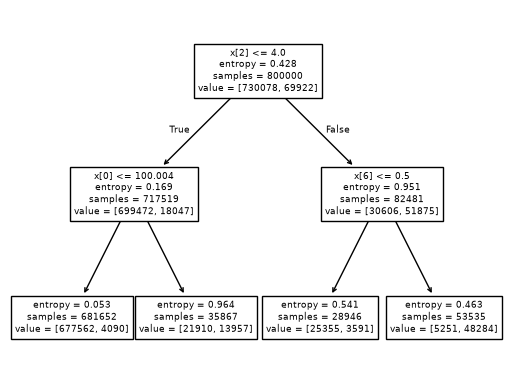

In [13]:
tree.plot_tree(dt)

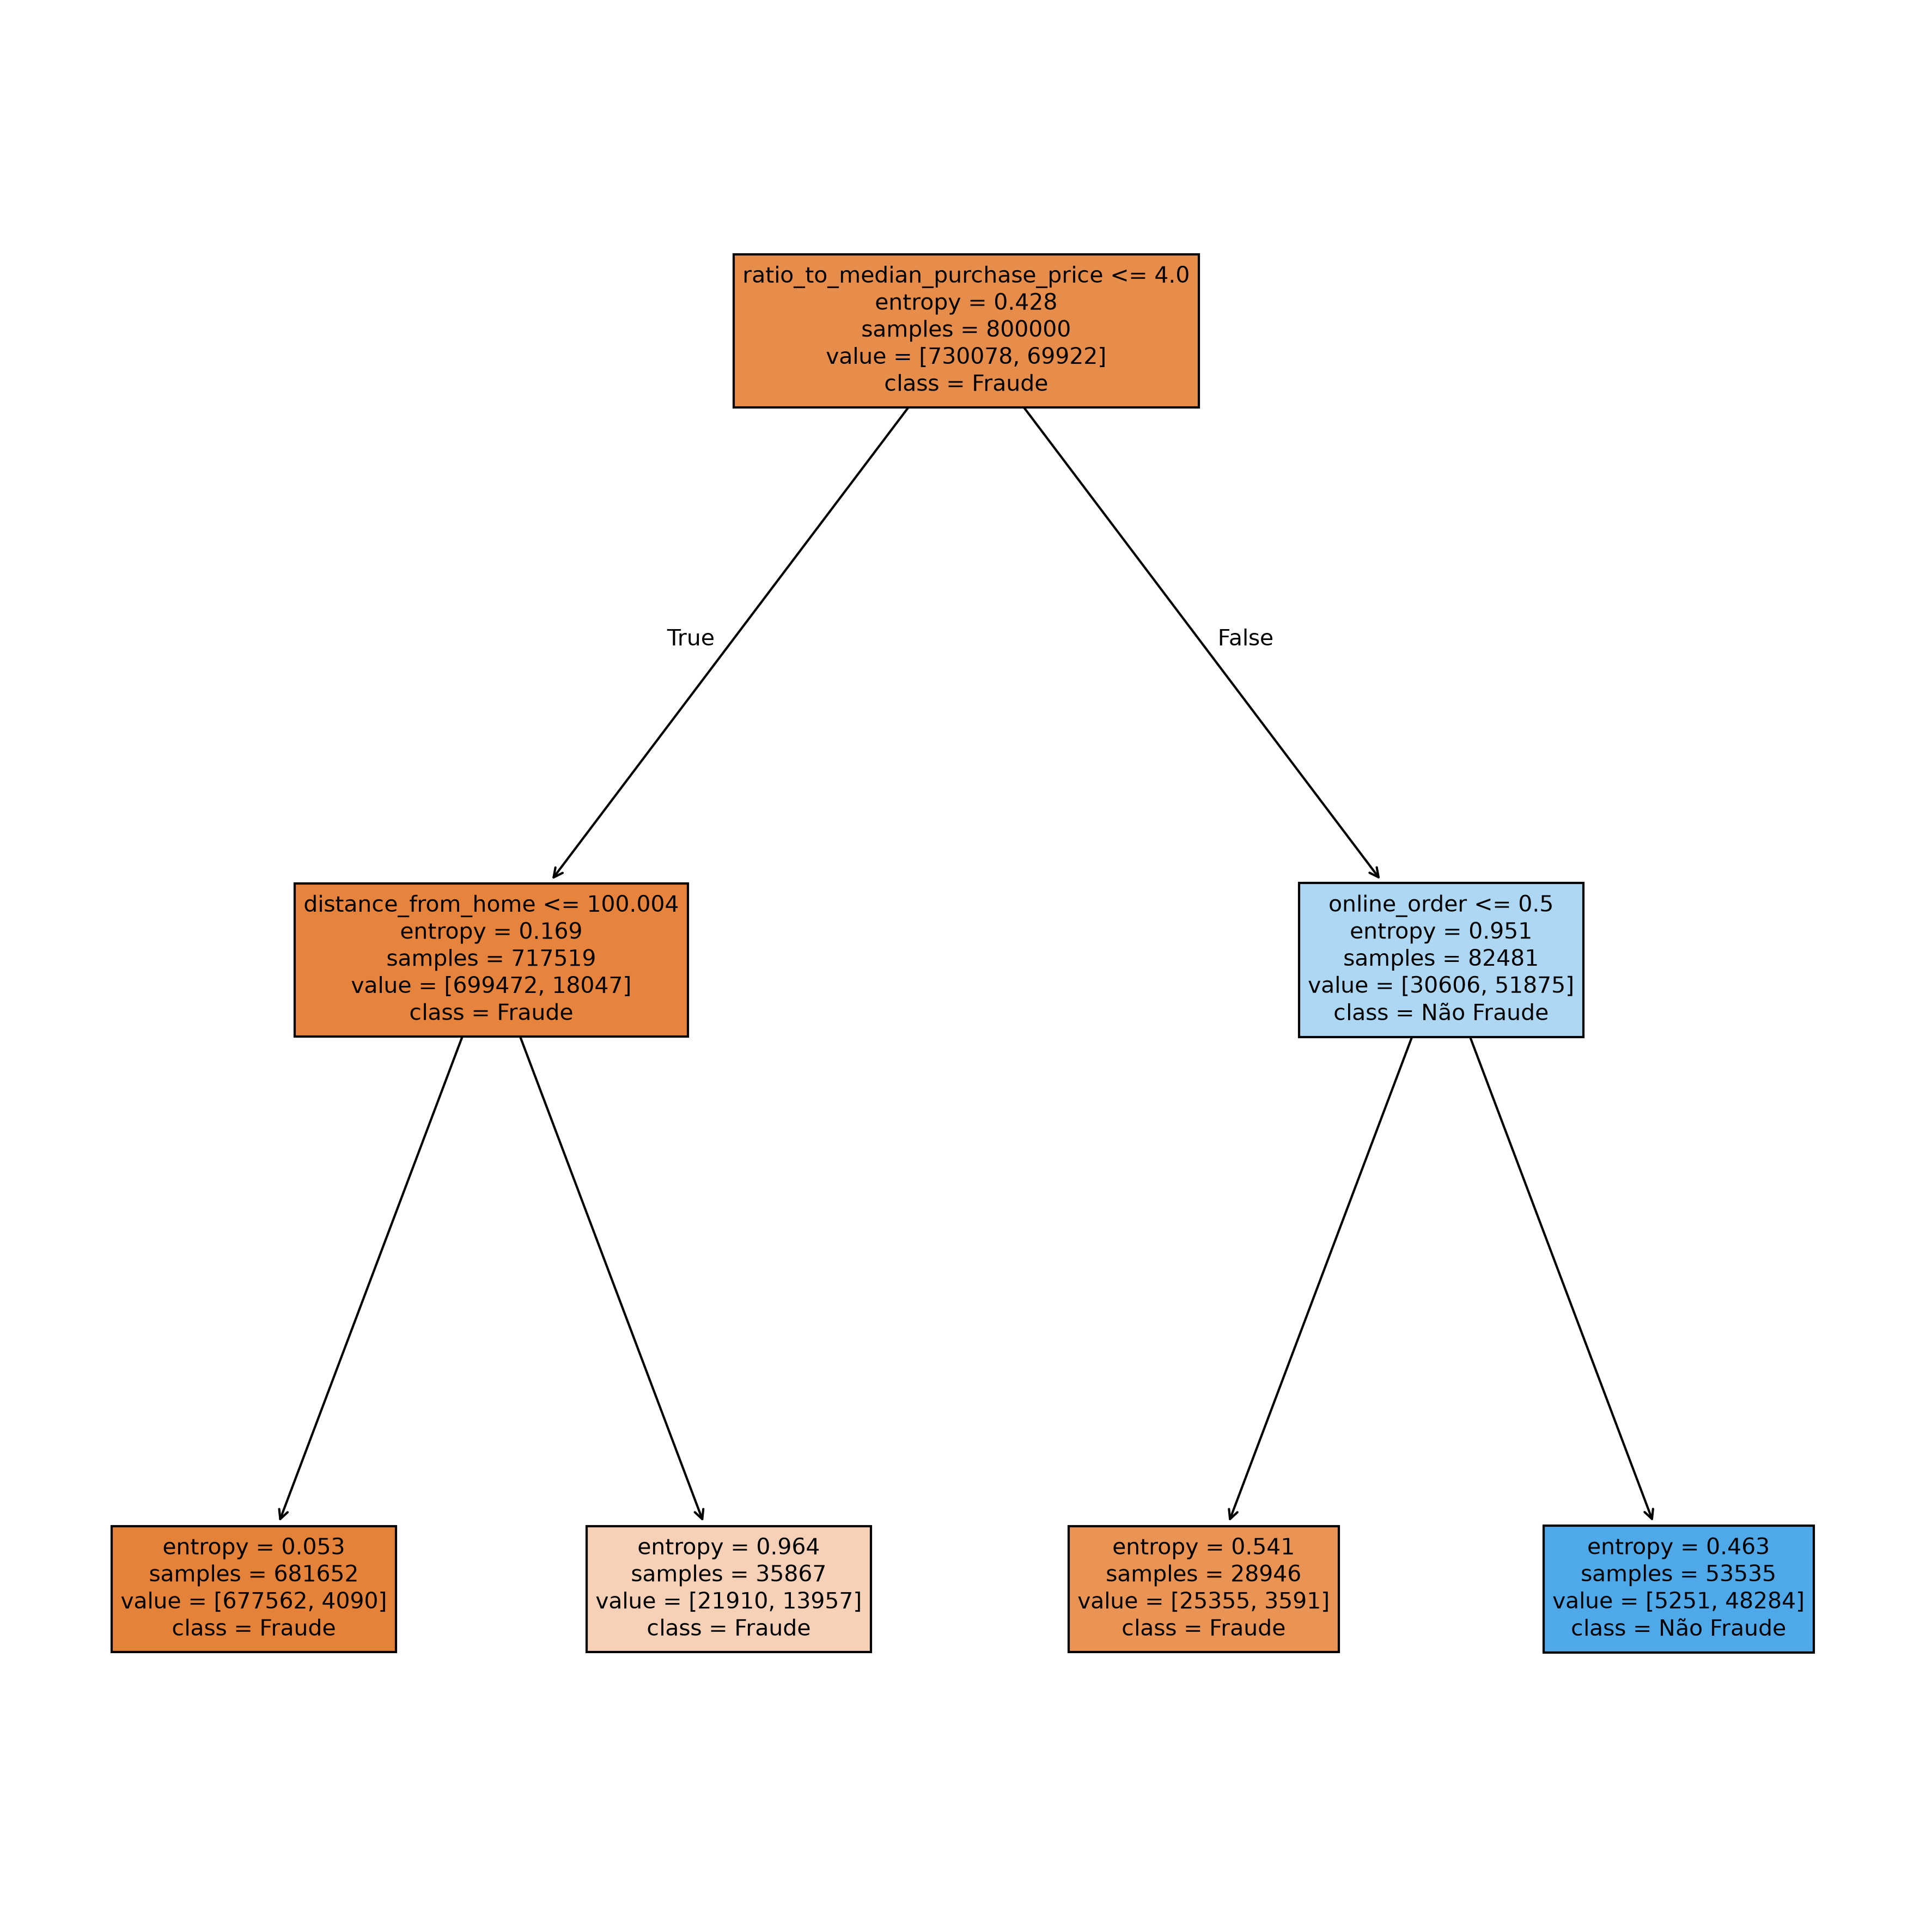

In [18]:
class_names = ['Fraude', 'Não Fraude'] # minha variavel target 

label_names = ['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price', 'repeat_retailer', 'used_chip', 'used_pin_number','online_order'] #todas as colunas ( sem o target) da minha base

fig, axes = plt.subplots(nrows = 1, ncols=1, figsize = (15,15), dpi =300)

tree.plot_tree(dt,
               feature_names =  label_names,
               class_names = class_names,
               filled = True)
fig.savefig('imagename.png')


In [20]:
from sklearn.metrics import accuracy_score 

In [21]:
# metricas de precisão, revocação, f1-score e acuracia
print(accuracy_score(y_test, y_predito))

0.96734


###Informações

Sample : quantidade de instancias de treinamento que se aplica ao nó (folha)
value : quantide de inst^nacias de treinamento de casa claasse que se aplica ao nó ( folha)
entropy : medida de impureza ( podemos utiliza t os coeficientes gini ou entropy) de um nó (entropy = 0 ) se todas as instancias de treinamento pertencem á mesma classe a qual se aplica.

Hiperparâmetros:
max_depth = quantidade de ramificações ( porfunidade da árvore). Reduzir o max_depth regulariza o modelo eciando assim o overfitting
min_sample_split : número minimo de amostrar que um nó deve ter antes de ser dividido 
min_samples_leaf: expressa como uma fração de npumero total de instancias ponderadas
max_features: npumero maximo de caracteristicas que vão ser avaliadas em casa divisão do no 
max_feature : numero maximo de caracteristicas que vao ser avaliadas em casa divisaão do nó
max_lead_nodes > número maximo de nos das folha.





In [49]:
#RANDOM FOREST

rf = RandomForestClassifier(n_estimators=6, max_depth=3, random_state=7)
rf.fit( x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",6
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",7
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bo

In [50]:
estimator = rf.estimators_

In [51]:
y_predito_random_forest = rf.predict(x_test)

In [52]:
#metricas de precisão
print(accuracy_score(y_test, y_predito_random_forest))

0.974845


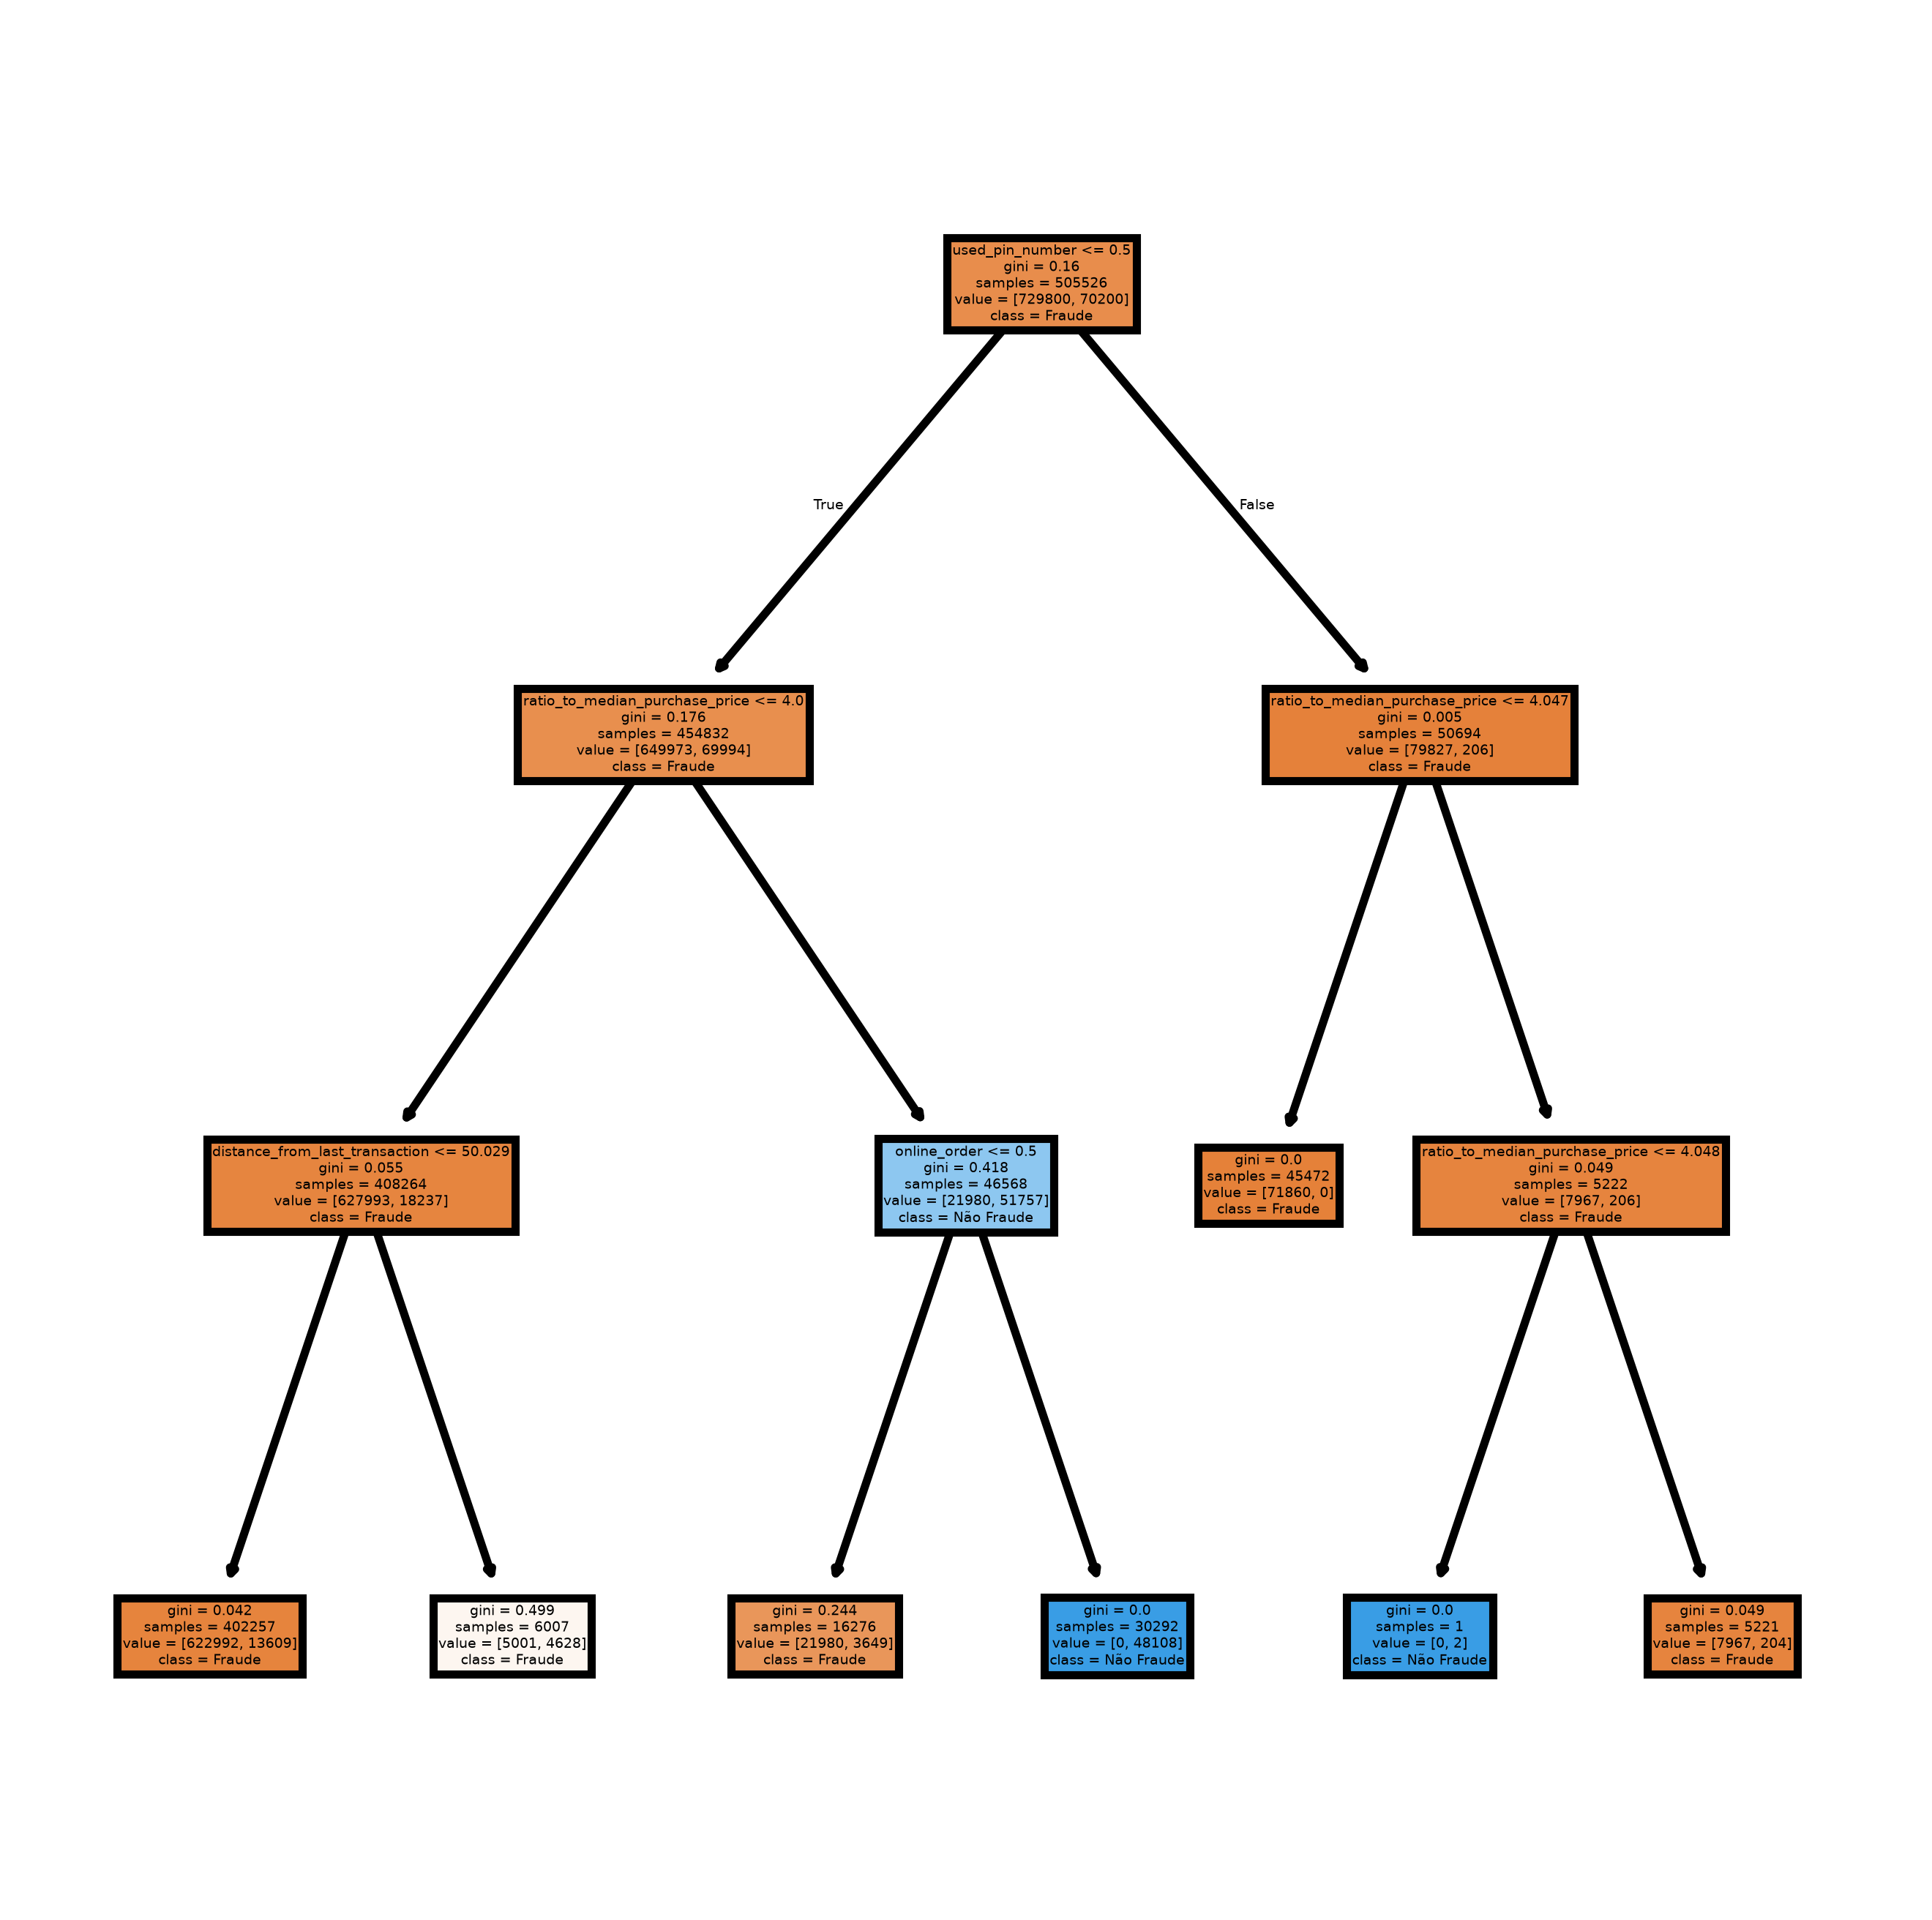

In [53]:
fig, axes = plt.subplots(nrows = 1, ncols = 1, figsize = (4,4), dpi= 800)
tree.plot_tree(rf.estimators_[0],
               feature_names = label_names,
               class_names = class_names,
               filled = True);
fig.savefig('rf_indicidualtree.png')  

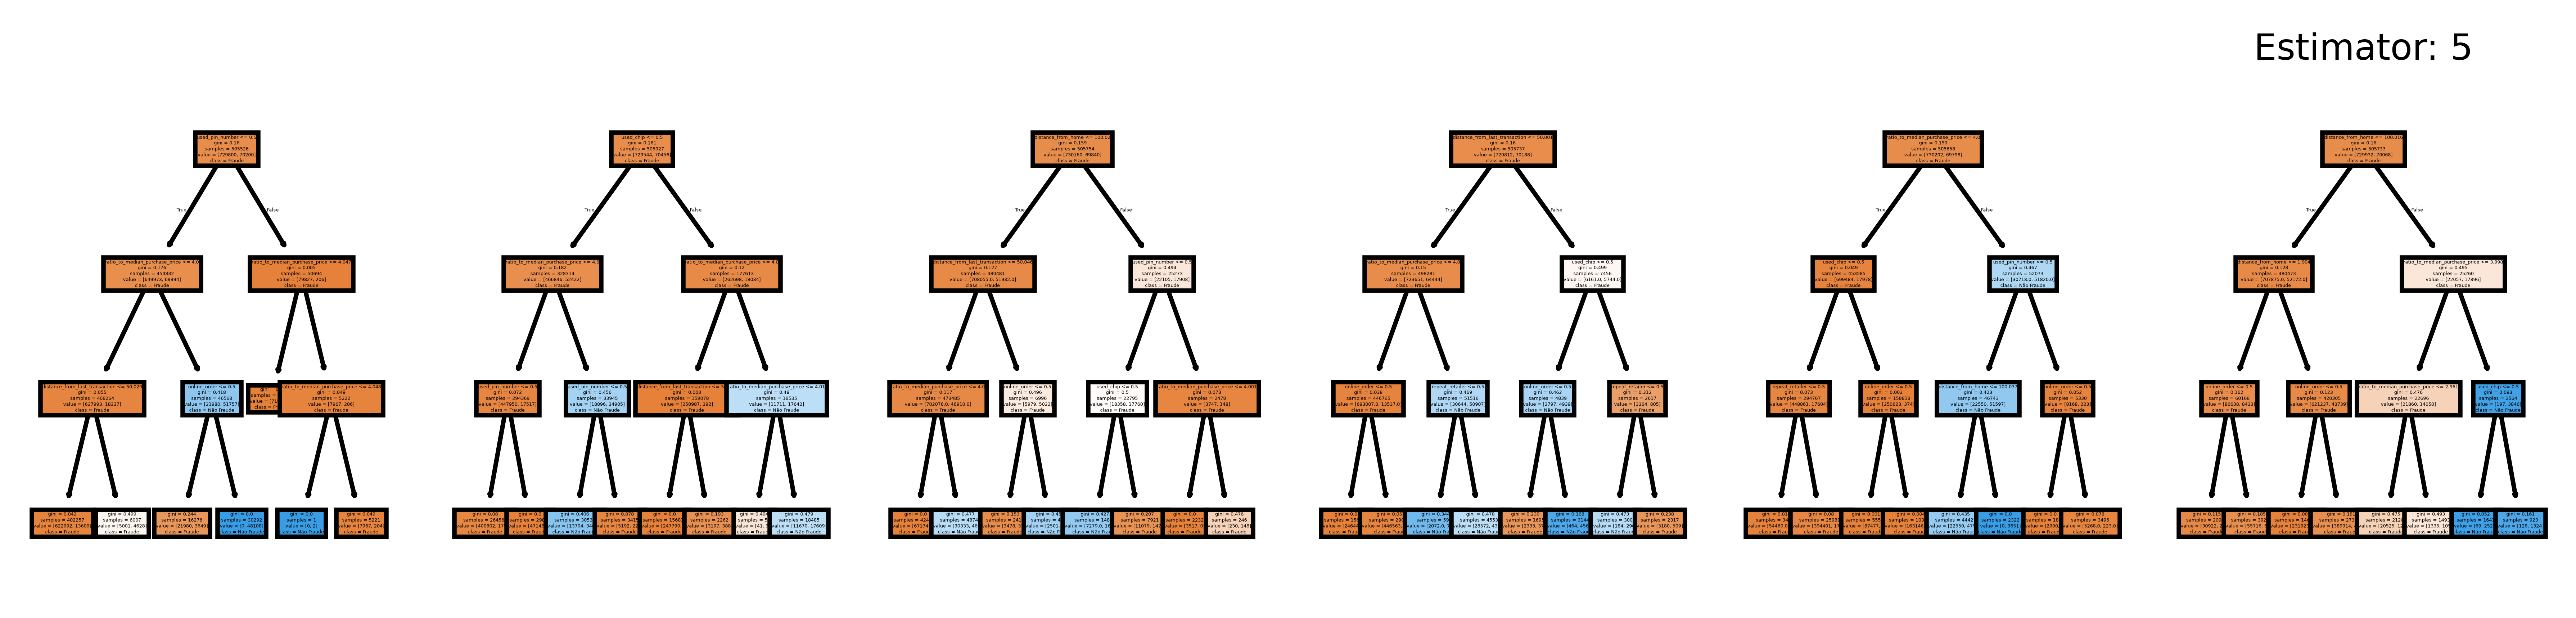

In [54]:
fig, axes = plt.subplots(nrows = 1 , ncols = 6, figsize = (10,2), dpi = 900)
for index in range (0,6):
    tree.plot_tree(rf.estimators_[index],
                   feature_names = label_names,
                   class_names = class_names,
                   filled = True,
                   ax = axes[index]);

axes[index].set_title('Estimator: ' + str(index), fontsize =8)
fig.savefig('rf_5trees.png')

In [55]:
#precisão media da floresta aleaatória nos dados fornecidos
print (rf.score(x_train, y_train))
print (rf.score(x_test, y_test))

0.9742825
0.974845
